# Process sensor stability

This notebook compares three Si2H6 flow runs and excludes the initial ramp-up interval before calculating stability statistics.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('../data/process_sensor_summary.csv')
data.head()

,run,process_time,si2h6_flow,target,stable_interval
0,Run1,1.0,33.91,200.0,False
1,Run1,2.0,191.01,200.0,False
2,Run1,3.0,201.14,200.0,False
3,Run1,4.0,200.55,200.0,True
4,Run1,5.0,200.35,200.0,True


In [2]:
stable = data.loc[data['stable_interval']].copy()
summary = stable.groupby('run')['si2h6_flow'].agg(['count','mean','std'])
summary['lower_3sigma'] = summary['mean'] - 3 * summary['std']
summary['upper_3sigma'] = summary['mean'] + 3 * summary['std']
summary.round(4)

,count,mean,std,lower_3sigma,upper_3sigma
run,,,,,
Run1,27,200.0693,0.1488,199.6229,200.5156
Run2,26,200.0496,0.1194,199.6913,200.4080
Run3,28,200.0111,0.1025,199.7036,200.3186


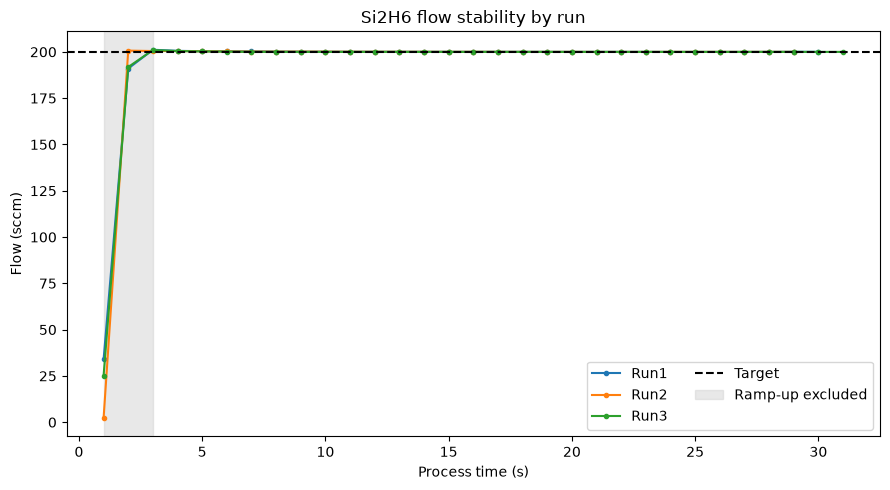

In [3]:
fig, ax = plt.subplots(figsize=(9,5))
for run, group in data.groupby('run'):
    ax.plot(group['process_time'], group['si2h6_flow'], marker='o', markersize=3, label=run)
ax.axhline(data['target'].median(), color='black', linestyle='--', label='Target')
ax.axvspan(data['process_time'].min(), 3, color='lightgray', alpha=.5, label='Ramp-up excluded')
ax.set(title='Si2H6 flow stability by run', xlabel='Process time (s)', ylabel='Flow (sccm)')
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig('../images/sensor_stability_by_run.png', dpi=180, bbox_inches='tight')
plt.show()

## Interpretation

The first three observations are treated as ramp-up, not steady-state evidence. Stability is assessed from the remaining samples using the sample mean, sample standard deviation, and an empirical mean ± 3σ band. This is a comparative exercise, not a validated production control limit.